In [88]:
#!pip install vaderSentiment

import pandas as pd
import numpy as np
import glob
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer
from sklearn.preprocessing import MinMaxScaler
import matplotlib.pyplot as plt
#!pip install wordcloud
from wordcloud import WordCloud
from wordcloud import STOPWORDS
#!pip install seaborn
import seaborn as sns
from sklearn.ensemble import RandomForestRegressor

scaler = MinMaxScaler()

In [47]:
import glob

files = glob.glob('../dataset/reviews_*.json')
print(len(files))  

100


In [48]:
analyzer = SentimentIntensityAnalyzer()

files = glob.glob('../dataset/reviews_*.json')

all_results = []

for i, file in enumerate(files):
    print(f"Processing {i+1}/{len(files)}")
    
    df = pd.read_json(file, lines=True)
    
    # speed boost
    df['text'] = df['text'].str[:300]
    
    df['sentiment'] = df['text'].apply(
        lambda x: analyzer.polarity_scores(x)['compound']
    )
    
    # free memory
    df = df[['business_id', 'stars', 'sentiment']]
    
    result = df.groupby('business_id').mean().reset_index()
    
    all_results.append(result)

final_df = pd.concat(all_results) \
    .groupby('business_id').mean().reset_index()

print(final_df.head())

Processing 1/100
Processing 2/100
Processing 3/100
Processing 4/100
Processing 5/100
Processing 6/100
Processing 7/100
Processing 8/100
Processing 9/100
Processing 10/100
Processing 11/100
Processing 12/100
Processing 13/100
Processing 14/100
Processing 15/100
Processing 16/100
Processing 17/100
Processing 18/100
Processing 19/100
Processing 20/100
Processing 21/100
Processing 22/100
Processing 23/100
Processing 24/100
Processing 25/100
Processing 26/100
Processing 27/100
Processing 28/100
Processing 29/100
Processing 30/100
Processing 31/100
Processing 32/100
Processing 33/100
Processing 34/100
Processing 35/100
Processing 36/100
Processing 37/100
Processing 38/100
Processing 39/100
Processing 40/100
Processing 41/100
Processing 42/100
Processing 43/100
Processing 44/100
Processing 45/100
Processing 46/100
Processing 47/100
Processing 48/100
Processing 49/100
Processing 50/100
Processing 51/100
Processing 52/100
Processing 53/100
Processing 54/100
Processing 55/100
Processing 56/100
P

In [49]:
final_df.to_csv('../dataset/business_sentiment.csv', index=False)

In [50]:
# Load both datasets
sentiment = pd.read_csv('../dataset/business_sentiment.csv')
restaurants = pd.read_csv('../dataset/restaurants.csv')

In [51]:
# Merge them
df_merged = sentiment.merge(restaurants, on='business_id', how='inner')
df_merged.head(5)

,business_id,stars_x,sentiment,name,city,state,stars_y,review_count,is_open,categories
0,---kPU91CF4Lq2-WlRu9Lw,4.590909,0.820627,Frankie's Raw Bar,New Port Richey,FL,4.5,24,1,"Seafood, Restaurants, Latin American, Food, Fo..."
1,--0iUa4sNDFiZFrAdIWhZQ,3.214286,0.485279,Pupuseria Y Restaurant Melba,Clementon,NJ,3.0,14,1,"Food, Restaurants, Specialty Food, Mexican, Et..."
2,--7PUidqRWpRSpXebiyxTg,1.750000,-0.052975,Humpty's Family Restaurant,Edmonton,AB,2.0,12,0,"Breakfast & Brunch, Restaurants"
3,--8IbOsAAxjKRoYsBFL-PA,2.923077,0.335104,The Original Italian Pie,Gentilly,LA,3.0,27,0,"Food, Restaurants, Italian"
4,--ZVrH2X2QXBFdCilbirsw,4.687500,0.741473,Chris's Sandwich Shop,Ardmore,PA,4.5,32,0,"American (Traditional), Restaurants, Pizza, Sa..."


In [52]:
df_merged = df_merged.rename(columns={'stars_x': 'stars'})
df_merged = df_merged.drop(columns=['stars_y'])

In [53]:
df_merged.head()

,business_id,stars,sentiment,name,city,state,review_count,is_open,categories
0,---kPU91CF4Lq2-WlRu9Lw,4.590909,0.820627,Frankie's Raw Bar,New Port Richey,FL,24,1,"Seafood, Restaurants, Latin American, Food, Fo..."
1,--0iUa4sNDFiZFrAdIWhZQ,3.214286,0.485279,Pupuseria Y Restaurant Melba,Clementon,NJ,14,1,"Food, Restaurants, Specialty Food, Mexican, Et..."
2,--7PUidqRWpRSpXebiyxTg,1.750000,-0.052975,Humpty's Family Restaurant,Edmonton,AB,12,0,"Breakfast & Brunch, Restaurants"
3,--8IbOsAAxjKRoYsBFL-PA,2.923077,0.335104,The Original Italian Pie,Gentilly,LA,27,0,"Food, Restaurants, Italian"
4,--ZVrH2X2QXBFdCilbirsw,4.687500,0.741473,Chris's Sandwich Shop,Ardmore,PA,32,0,"American (Traditional), Restaurants, Pizza, Sa..."


In [54]:
df_merged.info()

<class 'pandas.DataFrame'>
RangeIndex: 52252 entries, 0 to 52251
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   business_id   52252 non-null  str    
 1   stars         52252 non-null  float64
 2   sentiment     52252 non-null  float64
 3   name          52252 non-null  str    
 4   city          52252 non-null  str    
 5   state         52252 non-null  str    
 6   review_count  52252 non-null  int64  
 7   is_open       52252 non-null  int64  
 8   categories    52252 non-null  str    
dtypes: float64(2), int64(2), str(5)
memory usage: 3.6 MB


In [55]:
num_cities = df_merged[['city', 'state']].drop_duplicates().shape[0]
print(f"Number of unique cities: {num_cities}")

Number of unique cities: 941


In [56]:
# Aggregate by city
city_sentiment = df_merged.groupby(['city', 'state']).agg({
    'sentiment': 'mean',
    'stars': 'mean',
    'business_id': 'count'
}).reset_index()

city_sentiment = city_sentiment.rename(columns={
    'business_id': 'restaurant_count'
})

city_sentiment.sort_values(by='sentiment', ascending=False).head(10)

,city,state,sentiment,stars,restaurant_count
210,Eddington,PA,0.919800,4.200000,1
368,Kalispell,MT,0.918300,5.000000,1
434,Lutz fl,FL,0.912375,4.937500,1
719,Southeast Edmonton,AB,0.898671,3.571429,1
387,LOWER PROVIDENCE,PA,0.890420,4.963768,1
87,Bryn Athyn,PA,0.883675,4.750000,1
187,Drexel Heights,AZ,0.876743,4.571429,1
199,East Greenville,PA,0.865500,3.600000,1
320,Hancock,IN,0.847520,3.600000,1
820,Truckee,CA,0.844853,4.761364,1


In [57]:
# Combine with city scores
city_scores = pd.read_csv('../dataset/city_scores_v2.csv')

final_city = city_scores.merge(
    city_sentiment,
    on=['city', 'state'],
    how='left'
)

final_city.sort_values(by='sentiment', ascending=False).head(5)

,city,state,restaurant_count_x,avg_rating,total_reviews,avg_review_per_restaurant,norm_demand,norm_competition,norm_rating,opportunity_score,sentiment,stars,restaurant_count_y
10,Dunedin,FL,130,3.880769,15204,116.953846,0.028392,0.023035,0.965097,-0.185734,0.593291,3.822927,188
5,Santa Barbara,CA,445,3.915730,127058,285.523596,0.254765,0.113735,1.000000,-0.106738,0.591579,3.820033,766
104,New Hope,PA,53,3.622642,7004,132.150943,0.011797,0.000864,0.707399,-0.135841,0.564018,3.502622,99
95,Ardmore,PA,69,3.797101,6340,91.884058,0.010453,0.005471,0.881569,-0.172728,0.562472,3.694071,126
80,Doylestown,PA,101,3.663366,7491,74.168317,0.012782,0.014685,0.748056,-0.147625,0.560856,3.647805,156


## 2. Create The Sentiment Model

### V1: Naive first model

In [58]:
# Create enhanced score
# V1: Initial sentiment-enhanced model
final_city['opportunity_with_sentiment'] = (
    final_city['norm_demand'] * 0.4 +
    (1 - final_city['norm_competition']) * 0.3 +
    final_city['norm_rating'] * 0.2 +
    final_city['sentiment'] * 0.1
)

In [59]:
# Get top cities by this new score
final_city.sort_values(
    by='opportunity_with_sentiment',
    ascending=False
).head(5)

,city,state,restaurant_count_x,avg_rating,total_reviews,avg_review_per_restaurant,norm_demand,norm_competition,norm_rating,opportunity_score,sentiment,stars,restaurant_count_y,opportunity_with_sentiment
48,New Orleans,LA,1390,3.765108,386603,278.131655,0.780039,0.385834,0.849628,0.104344,0.551830,3.746318,2258,0.721374
5,Santa Barbara,CA,445,3.915730,127058,285.523596,0.254765,0.113735,1.000000,-0.106738,0.591579,3.820033,766,0.626944
89,Philadelphia,PA,3523,3.584871,495289,140.587284,1.000000,1.000000,0.669691,0.066062,0.504142,3.555700,5849,0.584352
10,Dunedin,FL,130,3.880769,15204,116.953846,0.028392,0.023035,0.965097,-0.185734,0.593291,3.822927,188,0.556795
117,Nashville,TN,1680,3.570833,260828,155.254762,0.525492,0.469335,0.655677,-0.009190,0.510851,3.566424,2502,0.551617


### V2: Fixed Model

In [60]:
# V2: Normalized sentiment (Fixed model)
final_city[['norm_sentiment']] = scaler.fit_transform(final_city[['sentiment']])

final_city['opportunity_with_sentiment_v2'] = (
    final_city['norm_demand'] * 0.4 +
    (1 - final_city['norm_competition']) * 0.3 +
    final_city['norm_rating'] * 0.2 +
    final_city['norm_sentiment'] * 0.1
)

In [61]:
# Get top cities by this new score
final_city.sort_values(
    by='opportunity_with_sentiment_v2',
    ascending=False
).head(5)

,city,state,restaurant_count_x,avg_rating,total_reviews,avg_review_per_restaurant,norm_demand,norm_competition,norm_rating,opportunity_score,sentiment,stars,restaurant_count_y,opportunity_with_sentiment,norm_sentiment,opportunity_with_sentiment_v2
48,New Orleans,LA,1390,3.765108,386603,278.131655,0.780039,0.385834,0.849628,0.104344,0.551830,3.746318,2258,0.721374,0.825280,0.748719
5,Santa Barbara,CA,445,3.915730,127058,285.523596,0.254765,0.113735,1.000000,-0.106738,0.591579,3.820033,766,0.626944,0.992782,0.667064
10,Dunedin,FL,130,3.880769,15204,116.953846,0.028392,0.023035,0.965097,-0.185734,0.593291,3.822927,188,0.556795,1.000000,0.597466
89,Philadelphia,PA,3523,3.584871,495289,140.587284,1.000000,1.000000,0.669691,0.066062,0.504142,3.555700,5849,0.584352,0.624320,0.596370
4,Carpinteria,CA,58,3.853448,9114,157.137931,0.016067,0.002303,0.937822,-0.180222,0.557589,3.708092,81,0.549059,0.849549,0.578255


### V3: Advance Model

In [62]:
# V3: Confidence-weighted sentiment
# Add a confidence factor
final_city['confidence'] = (final_city['total_reviews'] / final_city['total_reviews'].max()) ** 0.5

final_city['weighted_sentiment'] = (final_city['norm_sentiment'] * final_city['confidence'])

final_city['opportunity_with_sentiment_v3'] = (
    final_city['norm_demand'] * 0.4 +
    (1 - final_city['norm_competition']) * 0.3 +
    final_city['norm_rating'] * 0.2 +
    final_city['weighted_sentiment'] * 0.1
)

In [63]:
# Get top cities by this new score
final_city.sort_values(
    by='opportunity_with_sentiment_v3',
    ascending=False
).head(5)

,city,state,restaurant_count_x,avg_rating,total_reviews,avg_review_per_restaurant,norm_demand,norm_competition,norm_rating,opportunity_score,sentiment,stars,restaurant_count_y,opportunity_with_sentiment,norm_sentiment,opportunity_with_sentiment_v2,confidence,weighted_sentiment,opportunity_with_sentiment_v3
48,New Orleans,LA,1390,3.765108,386603,278.131655,0.780039,0.385834,0.849628,0.104344,0.551830,3.746318,2258,0.721374,0.825280,0.748719,0.883493,0.729130,0.739104
5,Santa Barbara,CA,445,3.915730,127058,285.523596,0.254765,0.113735,1.000000,-0.106738,0.591579,3.820033,766,0.626944,0.992782,0.667064,0.506491,0.502835,0.618069
89,Philadelphia,PA,3523,3.584871,495289,140.587284,1.000000,1.000000,0.669691,0.066062,0.504142,3.555700,5849,0.584352,0.624320,0.596370,1.000000,0.624320,0.596370
117,Nashville,TN,1680,3.570833,260828,155.254762,0.525492,0.469335,0.655677,-0.009190,0.510851,3.566424,2502,0.551617,0.652593,0.565791,0.725684,0.473577,0.547890
74,Reno,NV,797,3.583438,151258,189.784191,0.303742,0.215088,0.668261,-0.046308,0.516395,3.578328,1287,0.542262,0.675956,0.558218,0.552624,0.373550,0.527977


**Model Evolution**
- V1 (Naive model)
→ Sentiment added directly
→ Result: small cities dominate
- V2 (Improved model)
→ Sentiment normalized
→ Result: more balanced rankings
- V3 (Advanced model)
→ Sentiment weighted by review volume
→ Result: business-realistic insight

The initial sentiment-enhanced model **(V1) over-weighted smaller cities** due to unscaled sentiment values. I addressed this by normalizing sentiment (V2) and further improved robustness by introducing a confidence-weighted sentiment based on review volume (V3)

### 3. Visualization

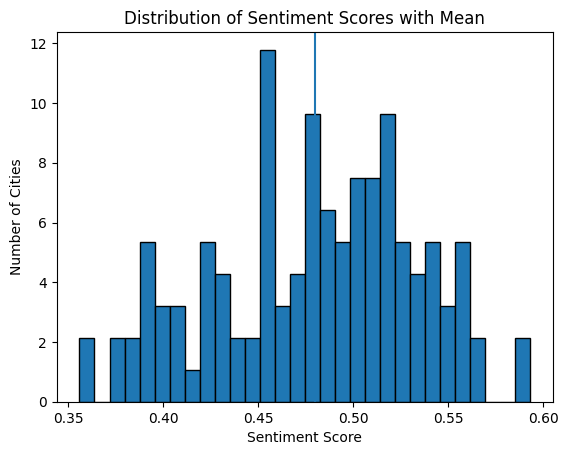

In [69]:
plt.figure()

plt.hist(final_city['sentiment'], bins=30, density=True, edgecolor='black')
plt.axvline(final_city['sentiment'].mean())

plt.title('Distribution of Sentiment Scores with Mean')
plt.xlabel('Sentiment Score')
plt.ylabel('Number of Cities')

plt.show()

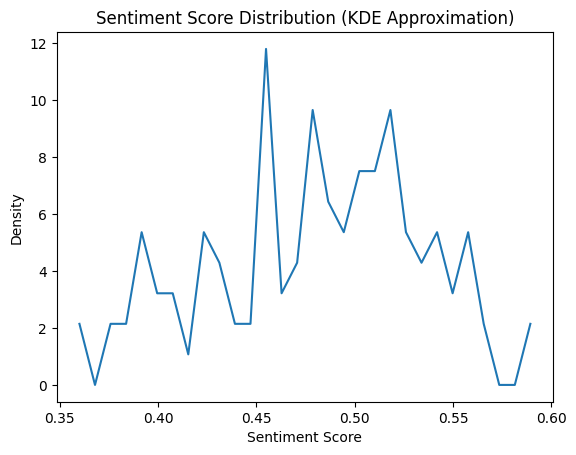

In [72]:
plt.figure()

data = final_city['sentiment'].dropna()
density = np.histogram(data, bins=30, density=True)
bins = density[1]
values = density[0]

# smooth line
bin_centers = (bins[:-1] + bins[1:]) / 2
plt.plot(bin_centers, values)

plt.title('Sentiment Score Distribution (KDE Approximation)')
plt.xlabel('Sentiment Score')
plt.ylabel('Density')

plt.show()

The sentiment distribution across 941 cities is tightly concentrated between approximately 0.45 and 0.55, with an average around 0.49. This indicates that customer perception is consistently positive across most markets, with limited variability between cities. As a result, sentiment alone provides weak differentiation and should be used as a supporting feature rather than a primary driver in the opportunity model.

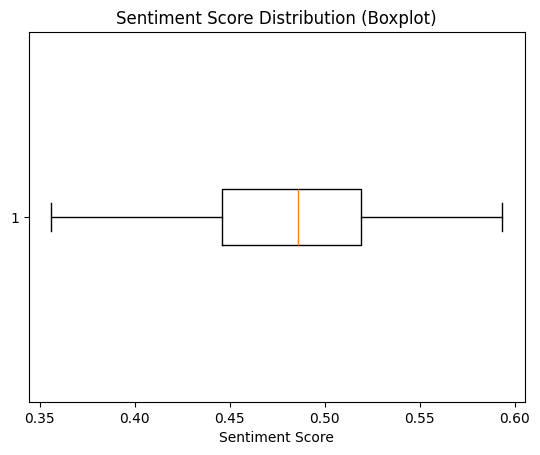

In [74]:
plt.figure()

plt.boxplot(final_city['sentiment'], vert=False)

plt.title('Sentiment Score Distribution (Boxplot)')
plt.xlabel('Sentiment Score')

plt.show()

With sentiment showing high consistency across cities, true market opportunity is better identified through structural gaps in demand and competition rather than marginal differences in customer perception.

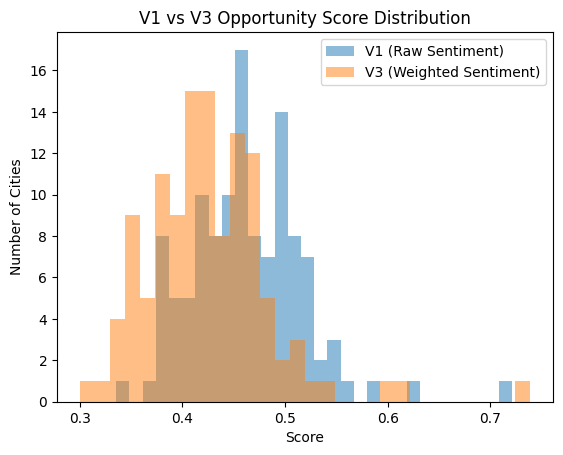

In [75]:
plt.figure()

plt.hist(final_city['opportunity_with_sentiment'], bins=30, alpha=0.5)
plt.hist(final_city['opportunity_with_sentiment_v3'], bins=30, alpha=0.5)

plt.title('V1 vs V3 Opportunity Score Distribution')
plt.xlabel('Score')
plt.ylabel('Number of Cities')

plt.legend(['V1 (Raw Sentiment)', 'V3 (Weighted Sentiment)'])

plt.show()

**V1 vs V3 Opportunity Score Distribution — Explanation**

The chart compares the distribution of opportunity scores between the initial model (V1), which uses raw sentiment, and the improved model (V3), which applies confidence-weighted sentiment.

- V1 (blue) shows a wider spread of scores, including more extreme high values
- V3 (orange) is more concentrated and slightly shifted toward the center

This indicates that V3 reduces the influence of extreme values and produces a more stable distribution of opportunity scores.

The transition from V1 to V3 demonstrates how incorporating confidence-weighted sentiment reduces noise and prevents overestimation of opportunity in smaller markets, resulting in a more balanced and reliable ranking model.

In [86]:
corr = final_city[['norm_demand','norm_competition','norm_rating','norm_sentiment']].corr()

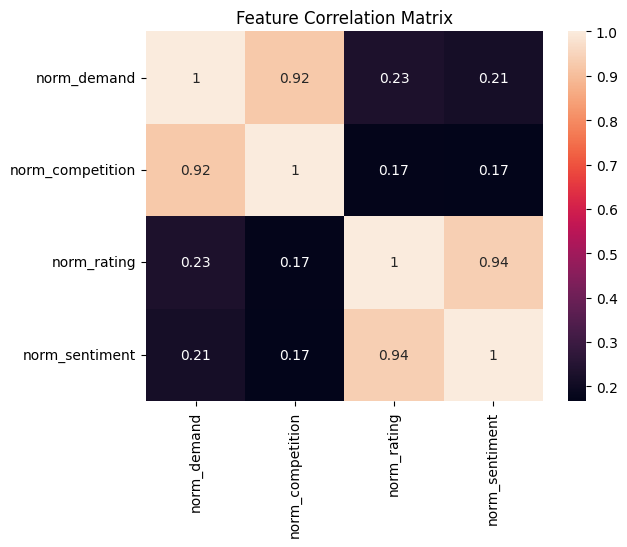

In [87]:
plt.figure()
sns.heatmap(corr, annot=True)
plt.title('Feature Correlation Matrix')
plt.show()

The analysis reveals **two distinct dimensions**: market activity (demand and competition) and customer satisfaction (rating and sentiment). While **demand and competition** are highly correlated, and **rating and sentiment** are nearly redundant, these two groups are largely independent. This suggests that opportunity is driven by **balancing market size** with quality gaps rather than relying on any single metric.

### 4. Check Feature importances

In [89]:
# Features
X = final_city[['norm_demand','norm_competition','norm_rating','norm_sentiment']]

# Target
y = final_city['opportunity_with_sentiment_v3']

# Train model
model = RandomForestRegressor(random_state=42)
model.fit(X, y)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsample

In [93]:
importance = model.feature_importances_
features = X.columns
feature_importance = pd.DataFrame({
    'feature': features,
    'importance': importance
}).sort_values(by='importance', ascending=False)

feature_importance

,feature,importance
2,norm_rating,0.703437
0,norm_demand,0.206266
1,norm_competition,0.050288
3,norm_sentiment,0.040010


The feature importance analysis reveals that rating is the dominant driver of the opportunity score, accounting for over 70% of the model’s influence. This is significantly higher than expected and can be attributed to the strong correlation between rating and sentiment, which effectively amplifies the impact of customer satisfaction within the model.

**=>The model unintentionally overweights customer satisfaction due to redundancy between rating and sentiment, highlighting the importance of careful feature selection and weighting in multi-factor models.**

### 5. Build V4 Model (Balance and Validated)

In [94]:
final_city['opportunity_with_sentiment_v4'] = (
    final_city['norm_demand'] * 0.45 +
    (1 - final_city['norm_competition']) * 0.30 +
    final_city['norm_rating'] * 0.20 +
    final_city['norm_sentiment'] * 0.05
)

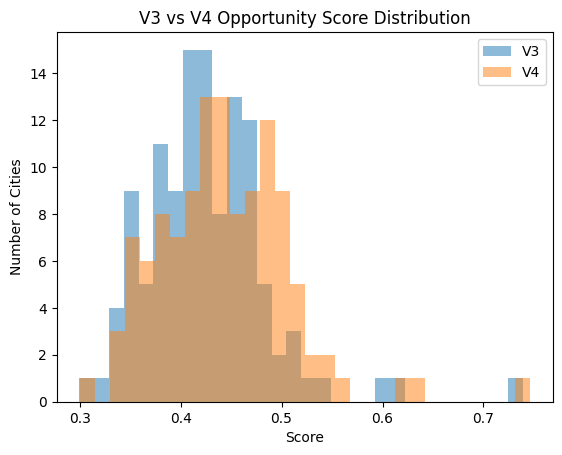

In [95]:
# Compare V3 and V4
plt.figure()

plt.hist(final_city['opportunity_with_sentiment_v3'], bins=30, alpha=0.5)
plt.hist(final_city['opportunity_with_sentiment_v4'], bins=30, alpha=0.5)

plt.title('V3 vs V4 Opportunity Score Distribution')
plt.xlabel('Score')
plt.ylabel('Number of Cities')

plt.legend(['V3', 'V4'])

plt.show()

The comparison between V3 and V4 highlights a clear improvement in model stability and balance. While V3 exhibited a wider spread with more extreme high scores, V4 produces a more concentrated distribution, indicating reduced sensitivity to outliers.

This improvement is driven by addressing feature redundancy between rating and sentiment, which previously caused an overemphasis on customer satisfaction signals. By rebalancing feature weights, V4 better reflects the underlying market dynamics of demand and competition.

In [96]:
# Get new top cities by V4
final_city.sort_values(
    by='opportunity_with_sentiment_v4',
    ascending=False
).head(10)

,city,state,restaurant_count_x,avg_rating,total_reviews,avg_review_per_restaurant,norm_demand,norm_competition,norm_rating,opportunity_score,sentiment,stars,restaurant_count_y,opportunity_with_sentiment,norm_sentiment,opportunity_with_sentiment_v2,confidence,weighted_sentiment,opportunity_with_sentiment_v3,opportunity_with_sentiment_v4
48,New Orleans,LA,1390,3.765108,386603,278.131655,0.780039,0.385834,0.849628,0.104344,0.551830,3.746318,2258,0.721374,0.825280,0.748719,0.883493,0.729130,0.739104,0.746457
5,Santa Barbara,CA,445,3.915730,127058,285.523596,0.254765,0.113735,1.000000,-0.106738,0.591579,3.820033,766,0.626944,0.992782,0.667064,0.506491,0.502835,0.618069,0.630163
89,Philadelphia,PA,3523,3.584871,495289,140.587284,1.000000,1.000000,0.669691,0.066062,0.504142,3.555700,5849,0.584352,0.624320,0.596370,1.000000,0.624320,0.596370,0.615154
117,Nashville,TN,1680,3.570833,260828,155.254762,0.525492,0.469335,0.655677,-0.009190,0.510851,3.566424,2502,0.551617,0.652593,0.565791,0.725684,0.473577,0.547890,0.559436
10,Dunedin,FL,130,3.880769,15204,116.953846,0.028392,0.023035,0.965097,-0.185734,0.593291,3.822927,188,0.556795,1.000000,0.597466,0.175206,0.175206,0.514986,0.548885
74,Reno,NV,797,3.583438,151258,189.784191,0.303742,0.215088,0.668261,-0.046308,0.516395,3.578328,1287,0.542262,0.675956,0.558218,0.552624,0.373550,0.527977,0.539607
4,Carpinteria,CA,58,3.853448,9114,157.137931,0.016067,0.002303,0.937822,-0.180222,0.557589,3.708092,81,0.549059,0.849549,0.578255,0.135652,0.115243,0.504824,0.536581
21,Tampa,FL,1965,3.626972,236140,120.173028,0.475528,0.551396,0.711722,-0.069999,0.513571,3.595587,2961,0.518494,0.664056,0.533542,0.690487,0.458522,0.512989,0.524116
95,Ardmore,PA,69,3.797101,6340,91.884058,0.010453,0.005471,0.881569,-0.172728,0.562472,3.694071,126,0.535101,0.870125,0.565866,0.113140,0.098446,0.488698,0.522883
30,Clearwater Beach,FL,54,3.768519,15892,294.296296,0.029785,0.001152,0.853033,-0.156060,0.539003,3.599747,77,0.536075,0.771227,0.559298,0.179127,0.138147,0.495990,0.522226


The analysis recommends prioritizing cities such as **New Orleans** and **Nashville**, where demand is strong and competition is not fully saturated. While high-demand markets like Philadelphia offer significant upside, they require stronger differentiation strategies. Smaller high-sentiment markets should be approached cautiously due to limited scale. Furthermore, Smaller cities like Dunedin and Carpinteria rank high due to strong ratings and sentiment but have low demand, making them less scalable for large investments.

In [99]:
# export final city data to csv (for Power BI dashboard decision supporting)

final_city.to_csv('../dataset/final_city.csv', index=False)

### 6. Conclusion

The final V4 opportunity model shows that cities like **New Orleans, Philadelphia, and Nashville** consistently rank among the top markets due to their strong combination of demand and overall market conditions.

The results indicate that:

**-High demand is a necessary but not sufficient condition** for opportunity, as it is strongly correlated with competition

**-Customer satisfaction (rating and sentiment) contributes to the model**, but does not independently drive rankings due to high redundancy between the two

**-Model refinement (V4)** successfully reduces the overemphasis on rating and sentiment, leading to a more balanced and realistic distribution of opportunity scores

From the rankings:

**-New Orleans emerges as the strongest overall opportunity**, offering high demand with relatively manageable competition

**-Philadelphia represents a high-demand but highly competitive market**, requiring strong differentiation

**-Nashville provides a balanced, lower-risk growth opportunity**

Additionally, smaller cities with high ratings and sentiment (e.g., Dunedin, Carpinteria) rank lower in the final model due to limited demand, highlighting the importance of scalability in market selection.